# Yellow taxi fare regression with PyTorch

End-to-end: **cleaning**, **imputation**, **feature selection**, optional **PCA**, then **comparisons** of shallow vs deep vs deep+dropout networks and of **activation functions** (ReLU, Tanh, Leaky ReLU, Sigmoid). The best model (by validation loss) is used for **example predictions** on the test set.

**Concepts and definitions:** see [`docs/CONCEPTS.md`](../docs/CONCEPTS.md).

**Data:** TLC yellow Parquet (`scripts/download_nyc_tlc_parquet.py`). Paths: `dataset_nyc_parquet/combined/yellow_all.parquet` or `dataset_nyc_parquet/yellow/`.

**Target:** `fare_amount`. Features avoid leakage from tips, tolls, taxes, and totals.


In [12]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))

sns.set_theme(style="whitegrid")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


## 1. Load data

Adjust `MAX_ROWS` for speed vs realism.


In [13]:
REPO_ROOT = Path("..").resolve()
MAX_ROWS = 250_000

def load_yellow_frame() -> pd.DataFrame:
    combined = REPO_ROOT / "dataset_nyc_parquet" / "combined" / "yellow_all.parquet"
    yellow_dir = REPO_ROOT / "dataset_nyc_parquet" / "yellow"
    if combined.is_file():
        return pd.read_parquet(combined, engine="pyarrow")
    if yellow_dir.is_dir():
        files = sorted(yellow_dir.glob("yellow_tripdata_*.parquet"))
        if not files:
            raise FileNotFoundError(f"No parquet files in {yellow_dir}")
        return pd.read_parquet(files[-1], engine="pyarrow")
    raise FileNotFoundError(
        "No yellow taxi data found. Run: python scripts/download_nyc_tlc_parquet.py --types yellow"
    )

df = load_yellow_frame()
if len(df) > MAX_ROWS:
    df = df.sample(n=MAX_ROWS, random_state=RANDOM_SEED).reset_index(drop=True)
print(df.shape)
df.head()


(250000, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-09-21 16:19:22,2024-09-21 16:31:10,1.0,1.66,1.0,N,125,186,1,12.1,0.0,0.5,3.22,0.0,1.0,19.32,2.5,0.0
1,1,2024-05-28 21:35:02,2024-05-28 21:58:33,1.0,4.90,1.0,N,100,41,1,24.0,3.5,0.5,5.80,0.0,1.0,34.80,2.5,0.0
2,2,2024-11-06 23:55:48,2024-11-07 00:13:03,1.0,2.77,1.0,N,230,144,1,17.7,1.0,0.5,4.54,0.0,1.0,27.24,2.5,0.0
3,2,2024-11-25 21:56:12,2024-11-25 22:15:48,1.0,4.08,1.0,N,68,239,1,21.9,1.0,0.5,5.38,0.0,1.0,32.28,2.5,0.0
4,2,2024-06-09 10:29:53,2024-06-09 10:32:53,1.0,0.80,1.0,N,68,68,1,5.8,0.0,0.5,1.96,0.0,1.0,11.76,2.5,0.0


## 2. Cleaning

Drop bad datetimes and impossible trips. **Imputation** for remaining missing values happens in sklearn pipelines below.


In [14]:
pickup_col = "tpep_pickup_datetime" if "tpep_pickup_datetime" in df.columns else "pickup_datetime"
dropoff_col = "tpep_dropoff_datetime" if "tpep_dropoff_datetime" in df.columns else "dropoff_datetime"

df[pickup_col] = pd.to_datetime(df[pickup_col], errors="coerce")
df[dropoff_col] = pd.to_datetime(df[dropoff_col], errors="coerce")

df = df.dropna(subset=[pickup_col, dropoff_col, "fare_amount", "trip_distance"])
df = df[df[dropoff_col] > df[pickup_col]]

df["trip_duration_sec"] = (df[dropoff_col] - df[pickup_col]).dt.total_seconds()

df = df[
    (df["fare_amount"] > 0)
    & (df["fare_amount"] < 500)
    & (df["trip_distance"] > 0)
    & (df["trip_distance"] < 100)
    & (df["trip_duration_sec"] > 60)
    & (df["trip_duration_sec"] < 4 * 3600)
].copy()

if "passenger_count" in df.columns:
    df["passenger_count"] = df["passenger_count"].clip(lower=1, upper=6)

print("Rows after cleaning:", len(df))
df[["fare_amount", "trip_distance", "trip_duration_sec"]].describe()


Rows after cleaning: 240102


,fare_amount,trip_distance,trip_duration_sec
count,240102.000000,240102.000000,240102.000000
mean,19.684988,3.414261,1014.731356
std,17.471836,4.419983,824.539776
min,0.010000,0.010000,61.000000
25%,9.300000,1.070000,479.000000
50%,14.200000,1.800000,784.000000
75%,22.600000,3.400000,1268.000000
max,429.300000,97.200000,14070.000000


## 3. Features (no fare-line leakage)

Exclude columns that encode the bill breakdown. Engineer time features.


In [15]:
LEAKAGE_COLS = {
    "tip_amount", "tolls_amount", "extra", "mta_tax", "improvement_surcharge",
    "total_amount", "congestion_surcharge", "airport_fee", "cbd_congestion_fee",
    "Airport_fee",
}

df["pickup_hour"] = df[pickup_col].dt.hour
df["pickup_dow"] = df[pickup_col].dt.dayofweek
df["pickup_month"] = df[pickup_col].dt.month

numeric_features = [
    "trip_distance", "trip_duration_sec", "pickup_hour", "pickup_dow", "pickup_month",
]
if "passenger_count" in df.columns:
    numeric_features.insert(1, "passenger_count")

cat_features = []
for c in ("RatecodeID", "payment_type", "VendorID"):
    if c in df.columns:
        cat_features.append(c)

for c in cat_features:
    df[c] = df[c].astype(str)

y = df["fare_amount"].astype(np.float32).values
X = df[numeric_features + cat_features].copy()

for c in LEAKAGE_COLS:
    if c in X.columns:
        X = X.drop(columns=[c])

X.head()


,trip_distance,passenger_count,trip_duration_sec,pickup_hour,pickup_dow,pickup_month,RatecodeID,payment_type,VendorID
0,1.66,1.0,708.0,16,5,9,1.0,1,2
1,4.90,1.0,1411.0,21,1,5,1.0,1,1
2,2.77,1.0,1035.0,23,2,11,1.0,1,2
3,4.08,1.0,1176.0,21,0,11,1.0,1,2
4,0.80,1.0,180.0,10,6,6,1.0,1,2


## 4. Train / validation / test split

Random split for the demo; time-based split is better for deployment.


In [16]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15 / 0.85, random_state=RANDOM_SEED
)
print("train", len(X_train), "val", len(X_val), "test", len(X_test))


train 168070 val 36016 test 36016


## 5. Preprocessing: impute → scale / one-hot → `SelectKBest` → optional PCA

See `docs/CONCEPTS.md` for definitions.


In [17]:
USE_PCA = True
K_BEST = 40
PCA_VAR = 0.95

num_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, max_categories=30),
        ),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, numeric_features),
        ("cat", cat_pipe, cat_features),
    ],
    remainder="drop",
)

X_tr = preprocess.fit_transform(X_train)
X_va = preprocess.transform(X_val)
X_te = preprocess.transform(X_test)

selector = SelectKBest(score_func=f_regression, k=min(K_BEST, X_tr.shape[1]))
X_tr_s = selector.fit_transform(X_tr, y_train)
X_va_s = selector.transform(X_va)
X_te_s = selector.transform(X_te)
print("After SelectKBest:", X_tr_s.shape[1])

if USE_PCA:
    pca = PCA(n_components=PCA_VAR, svd_solver="full")
    X_tr_s = pca.fit_transform(X_tr_s)
    X_va_s = pca.transform(X_va_s)
    X_te_s = pca.transform(X_te_s)
    print("PCA dims:", X_tr_s.shape[1], "variance:", float(pca.explained_variance_ratio_.sum()))

scaler_y = StandardScaler()
y_train_z = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel().astype(np.float32)
y_val_z = scaler_y.transform(y_val.reshape(-1, 1)).ravel().astype(np.float32)
y_test_z = scaler_y.transform(y_test.reshape(-1, 1)).ravel().astype(np.float32)

IN_DIM = X_tr_s.shape[1]


After SelectKBest: 20
PCA dims: 8 variance: 0.9729953560927849


## 6. DataLoaders


In [18]:
BATCH_SIZE = 2048


def make_loader(x: np.ndarray, y_arr: np.ndarray, shuffle: bool) -> DataLoader:
    ds = TensorDataset(
        torch.tensor(x, dtype=torch.float32),
        torch.tensor(y_arr, dtype=torch.float32).unsqueeze(1),
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False)


train_loader = make_loader(X_tr_s, y_train_z, shuffle=True)
val_loader = make_loader(X_va_s, y_val_z, shuffle=False)
test_loader = make_loader(X_te_s, y_test_z, shuffle=False)
IN_DIM


8

## 7. Activation shapes (illustration)

How ReLU, Tanh, Leaky ReLU, and Sigmoid behave on a 1D input range.


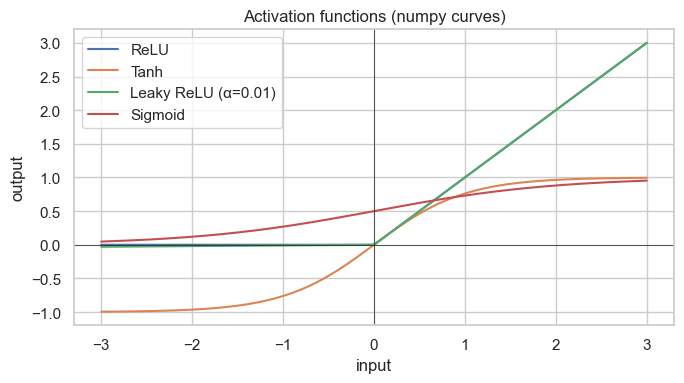

In [19]:
x = np.linspace(-3, 3, 300)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, np.maximum(0, x), label="ReLU")
ax.plot(x, np.tanh(x), label="Tanh")
ax.plot(x, np.where(x > 0, x, 0.01 * x), label="Leaky ReLU (α=0.01)")
ax.plot(x, 1 / (1 + np.exp(-x)), label="Sigmoid")
ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("input")
ax.set_ylabel("output")
ax.legend()
ax.set_title("Activation functions (numpy curves)")
plt.tight_layout()
plt.show()


## 8. Model factory, training loop, metrics

- **Early stopping** on validation MSE (scaled target).  
- **ReduceLROnPlateau** for learning-rate decay.  
- **AdamW** with weight decay.


In [20]:
def make_activation(name: str) -> nn.Module:
    n = name.lower()
    if n == "relu":
        return nn.ReLU(inplace=True)
    if n == "tanh":
        return nn.Tanh()
    if n == "leaky_relu":
        return nn.LeakyReLU(0.01, inplace=True)
    if n == "sigmoid":
        return nn.Sigmoid()
    raise ValueError(name)


class FareMLP(nn.Module):
    def __init__(
        self,
        in_features: int,
        hidden: tuple[int, ...],
        act_name: str = "relu",
        dropout_p: float = 0.0,
    ):
        super().__init__()
        layers: list[nn.Module] = []
        prev = in_features
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(make_activation(act_name))
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    train: bool,
) -> float:
    if train:
        model.train()
    else:
        model.eval()
    total = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        if train:
            assert optimizer is not None
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train):
            pred = model(xb)
            loss = criterion(pred, yb)
        if train:
            loss.backward()
            optimizer.step()
        total += loss.item() * xb.size(0)
        n += xb.size(0)
    return total / max(n, 1)


@torch.no_grad()
def metrics_dollars(model: nn.Module, loader: DataLoader) -> tuple[float, float, float]:
    model.eval()
    preds, actuals = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        pz = model(xb).cpu().numpy()
        preds.append(pz)
        actuals.append(yb.numpy())
    pz = np.vstack(preds).ravel()
    az = np.vstack(actuals).ravel()
    pred = scaler_y.inverse_transform(pz.reshape(-1, 1)).ravel()
    act = scaler_y.inverse_transform(az.reshape(-1, 1)).ravel()
    mae = mean_absolute_error(act, pred)
    rmse = root_mean_squared_error(act, pred)
    r2 = r2_score(act, pred)
    return mae, rmse, r2


def train_one_run(
    name: str,
    hidden: tuple[int, ...],
    act_name: str,
    dropout_p: float,
    seed_offset: int = 0,
    epochs: int = 100,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    patience: int = 12,
    verbose: bool = False,
) -> dict:
    torch.manual_seed(RANDOM_SEED + seed_offset)
    model = FareMLP(IN_DIM, hidden, act_name=act_name, dropout_p=dropout_p).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=4, min_lr=1e-6
    )

    history = {"train_mse": [], "val_mse": [], "lr": []}
    best_val = float("inf")
    best_state: dict | None = None
    stale = 0

    for epoch in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, criterion, optimizer, train=True)
        va = run_epoch(model, val_loader, criterion, None, train=False)
        scheduler.step(va)
        lr_now = optimizer.param_groups[0]["lr"]
        history["train_mse"].append(tr)
        history["val_mse"].append(va)
        history["lr"].append(lr_now)

        if va < best_val - 1e-8:
            best_val = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1

        if verbose and (epoch == 1 or epoch % 10 == 0):
            print(f"[{name}] epoch {epoch:03d} train_mse={tr:.5f} val_mse={va:.5f} lr={lr_now:.2e}")

        if stale >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    mae, rmse, r2 = metrics_dollars(model, test_loader)
    return {
        "name": name,
        "hidden": hidden,
        "act_name": act_name,
        "dropout_p": dropout_p,
        "best_val_mse": best_val,
        "test_mae": mae,
        "test_rmse": rmse,
        "test_r2": r2,
        "history": history,
        "model": model,
    }


## 9. Comparison A — architecture (fixed **ReLU**)

| Variant | Hidden layers | Dropout |
|---------|----------------|---------|
| Shallow | (64, 32) | 0 |
| Deep | (128, 96, 64, 32) | 0 |
| Deep + dropout | (128, 96, 64, 32) | 0.25 |

Lower **test MAE** is better (same test set for all; for rigorous model selection use validation only).


[shallow_relu] epoch 001 train_mse=0.16502 val_mse=0.08963 lr=1.00e-03
[shallow_relu] epoch 010 train_mse=0.07803 val_mse=0.07728 lr=1.00e-03
[shallow_relu] epoch 020 train_mse=0.07476 val_mse=0.07512 lr=1.00e-03
[shallow_relu] epoch 030 train_mse=0.07233 val_mse=0.07405 lr=1.00e-03
[shallow_relu] epoch 040 train_mse=0.07021 val_mse=0.07158 lr=5.00e-04
[shallow_relu] epoch 050 train_mse=0.06877 val_mse=0.07111 lr=5.00e-04
[shallow_relu] epoch 060 train_mse=0.06835 val_mse=0.06976 lr=5.00e-04
[shallow_relu] epoch 070 train_mse=0.06701 val_mse=0.06914 lr=2.50e-04
[shallow_relu] epoch 080 train_mse=0.06636 val_mse=0.06890 lr=1.25e-04
[shallow_relu] epoch 090 train_mse=0.06593 val_mse=0.06881 lr=6.25e-05
[shallow_relu] epoch 100 train_mse=0.06584 val_mse=0.06868 lr=1.56e-05
[deep_relu] epoch 001 train_mse=0.10762 val_mse=0.08063 lr=1.00e-03
[deep_relu] epoch 010 train_mse=0.07074 val_mse=0.07037 lr=1.00e-03
[deep_relu] epoch 020 train_mse=0.06778 val_mse=0.06804 lr=1.00e-03
[deep_relu] epo

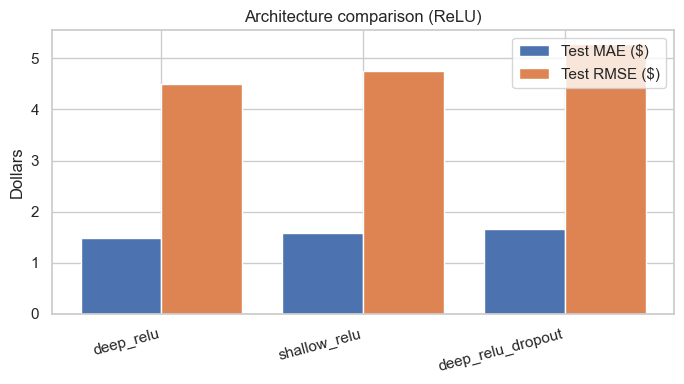


Lowest test MAE in this run (architecture sweep): deep_relu


In [21]:
arch_results = []
arch_results.append(
    train_one_run("shallow_relu", (64, 32), "relu", 0.0, seed_offset=1, verbose=True)
)
arch_results.append(
    train_one_run("deep_relu", (128, 96, 64, 32), "relu", 0.0, seed_offset=2, verbose=True)
)
arch_results.append(
    train_one_run("deep_relu_dropout", (128, 96, 64, 32), "relu", 0.25, seed_offset=3, verbose=True)
)

arch_df = pd.DataFrame(
    [
        {
            "model": r["name"],
            "best_val_mse_scaled": r["best_val_mse"],
            "test_mae_$": r["test_mae"],
            "test_rmse_$": r["test_rmse"],
            "test_R2": r["test_r2"],
        }
        for r in arch_results
    ]
)
arch_df = arch_df.sort_values("test_mae_$").reset_index(drop=True)
print(arch_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(arch_df))
ax.bar(x - 0.2, arch_df["test_mae_$"], 0.4, label="Test MAE ($)")
ax.bar(x + 0.2, arch_df["test_rmse_$"], 0.4, label="Test RMSE ($)")
ax.set_xticks(x)
ax.set_xticklabels(arch_df["model"], rotation=15, ha="right")
ax.set_ylabel("Dollars")
ax.legend()
ax.set_title("Architecture comparison (ReLU)")
plt.tight_layout()
plt.show()

best_arch_name = arch_df.loc[arch_df["test_mae_$"].idxmin(), "model"]
print(f"\nLowest test MAE in this run (architecture sweep): {best_arch_name}")


## 10. Comparison B — activations (fixed **deep + dropout**)

Same hidden sizes `(128, 96, 64, 32)` and `dropout=0.25`; only the hidden activation changes. Output layer stays **linear** (regression).


[deep_do_relu] epoch 001 train_mse=0.25989 val_mse=0.09133 lr=1.00e-03
[deep_do_relu] epoch 010 train_mse=0.12014 val_mse=0.08683 lr=5.00e-04
[deep_do_relu] epoch 020 train_mse=0.11403 val_mse=0.08178 lr=5.00e-04
[deep_do_relu] epoch 030 train_mse=0.11203 val_mse=0.08305 lr=2.50e-04
[deep_do_relu] epoch 040 train_mse=0.10828 val_mse=0.08173 lr=2.50e-04
[deep_do_tanh] epoch 001 train_mse=0.34666 val_mse=0.20415 lr=1.00e-03
[deep_do_tanh] epoch 010 train_mse=0.18964 val_mse=0.14827 lr=1.00e-03
[deep_do_tanh] epoch 020 train_mse=0.15812 val_mse=0.13425 lr=1.00e-03
[deep_do_tanh] epoch 030 train_mse=0.14299 val_mse=0.12465 lr=1.00e-03
[deep_do_tanh] epoch 040 train_mse=0.13411 val_mse=0.11845 lr=1.00e-03
[deep_do_tanh] epoch 050 train_mse=0.12525 val_mse=0.11040 lr=1.00e-03
[deep_do_tanh] epoch 060 train_mse=0.11848 val_mse=0.10382 lr=1.00e-03
[deep_do_tanh] epoch 070 train_mse=0.11470 val_mse=0.10000 lr=1.00e-03
[deep_do_tanh] epoch 080 train_mse=0.11152 val_mse=0.09527 lr=5.00e-04
[deep_

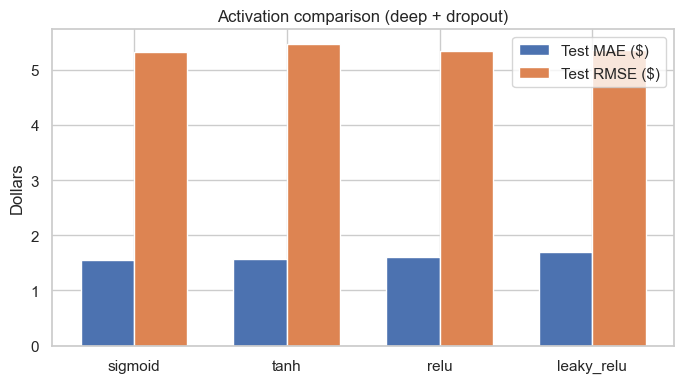


Champion (lowest val MSE among activations): deep_do_relu — act=relu, test MAE=$1.60


In [22]:
act_names = ["relu", "tanh", "leaky_relu", "sigmoid"]
act_results = []
for i, act in enumerate(act_names):
    act_results.append(
        train_one_run(
            f"deep_do_{act}",
            (128, 96, 64, 32),
            act,
            0.25,
            seed_offset=10 + i,
            verbose=True,
        )
    )

act_df = pd.DataFrame(
    [
        {
            "activation": r["act_name"],
            "best_val_mse_scaled": r["best_val_mse"],
            "test_mae_$": r["test_mae"],
            "test_rmse_$": r["test_rmse"],
            "test_R2": r["test_r2"],
        }
        for r in act_results
    ]
)
act_df = act_df.sort_values("test_mae_$").reset_index(drop=True)
print(act_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(act_df))
w = 0.35
ax.bar(x - w / 2, act_df["test_mae_$"], w, label="Test MAE ($)")
ax.bar(x + w / 2, act_df["test_rmse_$"], w, label="Test RMSE ($)")
ax.set_xticks(x)
ax.set_xticklabels(act_df["activation"])
ax.set_ylabel("Dollars")
ax.legend()
ax.set_title("Activation comparison (deep + dropout)")
plt.tight_layout()
plt.show()

# Champion = best validation MSE (matches early-stopping objective)
best_act_row = min(act_results, key=lambda r: r["best_val_mse"])
champion = best_act_row
print(
    f"\nChampion (lowest val MSE among activations): {champion['name']} "
    f"— act={champion['act_name']}, test MAE=${champion['test_mae']:.2f}"
)


## 11. Example predictions (champion on **test**)

Table of sample rows: actual fare, prediction, error. The champion model is the activation sweep winner (by validation MSE).


In [23]:
champ = champion["model"]
champ.eval()

# Build a small batch from test features + original rows for readable columns
n_show = 15
# Align test indices: use first n_show rows from X_test for feature context
idx = np.arange(n_show)
X_samp = X_test.iloc[idx].reset_index(drop=True)
y_samp = y_test[idx]

with torch.no_grad():
    xb = torch.tensor(X_te_s[idx], dtype=torch.float32, device=DEVICE)
    pred_z = champ(xb).cpu().numpy().ravel()
pred = scaler_y.inverse_transform(pred_z.reshape(-1, 1)).ravel()

pred_tbl = pd.DataFrame(
    {
        "trip_mi": X_samp["trip_distance"].values,
        "dur_min": (X_samp["trip_duration_sec"].values / 60).round(1),
        "hour": X_samp["pickup_hour"].values,
        "actual_fare": y_samp,
        "predicted_fare": np.round(pred, 2),
        "error_$": np.round(pred - y_samp, 2),
    }
)
pred_tbl


,trip_mi,dur_min,hour,actual_fare,predicted_fare,error_$
0,3.18,12.9,22,18.139999,18.629999,0.49
1,0.82,7.1,12,7.900000,8.480000,0.58
2,3.65,19.1,8,21.200001,20.559999,-0.64
3,3.51,22.8,11,21.900000,22.190001,0.29
4,0.90,5.1,17,6.500000,7.550000,1.05
5,2.21,13.4,0,14.200000,14.720000,0.52
6,2.41,27.5,14,24.000000,22.410000,-1.59
7,3.00,12.4,3,16.299999,15.110000,-1.19
8,2.50,17.4,17,17.000000,16.400000,-0.60
9,1.80,14.0,12,18.170000,13.950000,-4.22


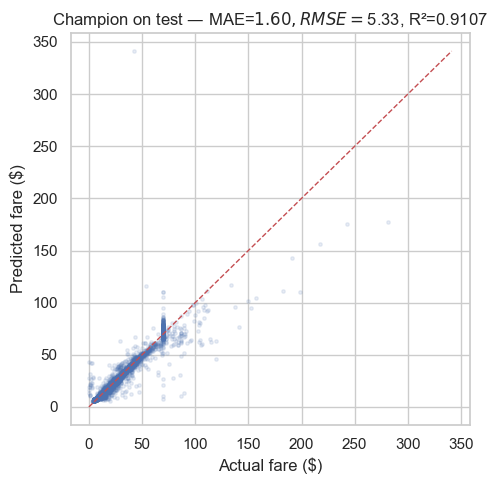

In [24]:
fig, ax = plt.subplots(figsize=(5, 5))
# Full test scatter (champion)
mae, rmse, r2 = metrics_dollars(champ, test_loader)
sample = min(8000, len(y_test))
rng = np.random.default_rng(RANDOM_SEED)
pick = rng.choice(len(y_test), size=sample, replace=False)
with torch.no_grad():
    xb = torch.tensor(X_te_s[pick], dtype=torch.float32, device=DEVICE)
    pz = champ(xb).cpu().numpy().ravel()
pred_f = scaler_y.inverse_transform(pz.reshape(-1, 1)).ravel()
act_f = y_test[pick]
ax.scatter(act_f, pred_f, alpha=0.12, s=6)
mx = max(act_f.max(), pred_f.max())
ax.plot([0, mx], [0, mx], "r--", lw=1)
ax.set_xlabel("Actual fare ($)")
ax.set_ylabel("Predicted fare ($)")
ax.set_title(f"Champion on test — MAE=${mae:.2f}, RMSE=${rmse:.2f}, R²={r2:.4f}")
plt.tight_layout()
plt.show()


## 12. Summary

- **Architecture:** Compare shallow vs deep vs deep+dropout with ReLU; deeper nets often benefit from **dropout** on tabular data when they overfit.  
- **Activations:** ReLU / Leaky ReLU often train faster than **sigmoid** in deeper nets; your **test** ranking may differ slightly each run.  
- **Champion selection** used **validation MSE** (scaled) to align with training; metrics on **test** are reported for all models.

Re-read definitions in [`docs/CONCEPTS.md`](../docs/CONCEPTS.md).
